# ☕ Coffee Vending Machine | Time Series Analysis
> Прогнозирование выручки, декомпозиция трендов и сезонности на основе транзакций 2024–2025.
> Цель: понять структуру спроса во времени и предсказать будущие продажи.

## ⚙️ 0. Настройка окружения и палитра

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# палитра: светлый кофе 
BG      = '#FAF3EB'   # cream paper
PANEL   = '#F0E6D3'   # latte foam
GRID    = '#D9C4A8'   # pale roast
TEXT    = '#2E1A0E'   # dark espresso
ACCENT  = '#8B3A0F'   # burnt sienna
ACCENT2 = '#C0692A'   # cinnamon
ACCENT3 = '#E89C55'   # caramel drizzle
ACCENT4 = '#6B4C35'   # mocha shadow
ACCENT5 = '#D4A76A'   # honey oat
PALETTE = [ACCENT, ACCENT2, ACCENT3, ACCENT4, ACCENT5,
           '#A0522D', '#CD853F', '#DEB887']

plt.rcParams.update({
    'figure.facecolor':  BG,
    'axes.facecolor':    PANEL,
    'axes.edgecolor':    GRID,
    'axes.labelcolor':   TEXT,
    'axes.titlecolor':   TEXT,
    'axes.titlesize':    14,
    'axes.titleweight':  'bold',
    'axes.titlepad':     14,
    'axes.grid':         True,
    'grid.color':        GRID,
    'grid.linewidth':    0.6,
    'xtick.color':       TEXT,
    'ytick.color':       TEXT,
    'text.color':        TEXT,
    'font.family':       'DejaVu Sans',
    'legend.facecolor':  PANEL,
    'legend.edgecolor':  GRID,
    'legend.labelcolor': TEXT,
    'figure.dpi':        110,
})

def style_ax(ax, title='', xlabel='', ylabel=''):
    ax.set_title(title)
    ax.set_xlabel(xlabel, labelpad=6)
    ax.set_ylabel(ylabel, labelpad=6)
    ax.spines[['top','right','left','bottom']].set_color(GRID)
    return ax

print('настройки готовы')

настройки готовы


## 📥 1. Загрузка и подготовка данных

In [5]:
PATH_2024 = '/Users/aomine/Desktop/coffee/index_1.csv' 
PATH_2025 = '/Users/aomine/Desktop/coffee/index_2.csv'

df24 = pd.read_csv(PATH_2024)
df25 = pd.read_csv(PATH_2025)
df = pd.concat([df24, df25], ignore_index=True)

df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
df['date']     = pd.to_datetime(df['date'],     errors='coerce')
df = df.dropna(subset=['datetime']).sort_values('datetime').reset_index(drop=True)

df['coffee_name'] = df['coffee_name'].str.strip()
df['hour']        = df['datetime'].dt.hour
df['weekday']     = df['datetime'].dt.day_name()
df['weekday_n']   = df['datetime'].dt.dayofweek
df['month']       = df['datetime'].dt.to_period('M').astype(str)
df['week']        = df['datetime'].dt.to_period('W').astype(str)
df['year']        = df['datetime'].dt.year

print(f'Транзакций : {len(df):,}')
print(f'Период     : {df["datetime"].min().date()} → {df["datetime"].max().date()}')
print(f'Напитков   : {df["coffee_name"].nunique()}')
print(f'Выручка    : {df["money"].sum():,.1f} грн')
df.head(3)

Транзакций : 3,636
Период     : 2024-03-01 → 2025-03-23
Напитков   : 8
Выручка    : 115,431.6 грн


,date,datetime,cash_type,card,money,coffee_name,hour,weekday,weekday_n,month,week,year
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte,10,Friday,4,2024-03,2024-02-26/2024-03-03,2024
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate,12,Friday,4,2024-03,2024-02-26/2024-03-03,2024
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate,12,Friday,4,2024-03,2024-02-26/2024-03-03,2024


## 📅 2. Временные ряды: дневная, недельная, месячная агрегация
> Строим три уровня детализации, они понадобятся и для анализа, и для моделей.

In [7]:
# Агрегация по дням
daily = df.set_index('datetime').resample('D')['money'].agg(
    revenue='sum', transactions='count'
).reset_index()
daily.columns = ['date','revenue','transactions']

# Недельная
weekly = df.set_index('datetime').resample('W')['money'].agg(
    revenue='sum', transactions='count'
).reset_index()
weekly.columns = ['date','revenue','transactions']

# Месячная
monthly = df.set_index('datetime').resample('ME')['money'].agg(
    revenue='sum', transactions='count'
).reset_index()
monthly.columns = ['date','revenue','transactions']
monthly['avg_check'] = monthly['revenue'] / monthly['transactions']

print(f'Дней в ряде    : {len(daily)}')
print(f'Недель в ряде  : {len(weekly)}')
print(f'Месяцев в ряде : {len(monthly)}')
daily.head(3)

Дней в ряде    : 388
Недель в ряде  : 56
Месяцев в ряде : 13


,date,revenue,transactions
0,2024-03-01,396.3,11
1,2024-03-02,228.1,7
2,2024-03-03,349.1,10


## 📈 3. Визуализация сырых рядов
> Смотрим что вообще происходит: дневной шум, недельное сглаживание, месячный тренд.

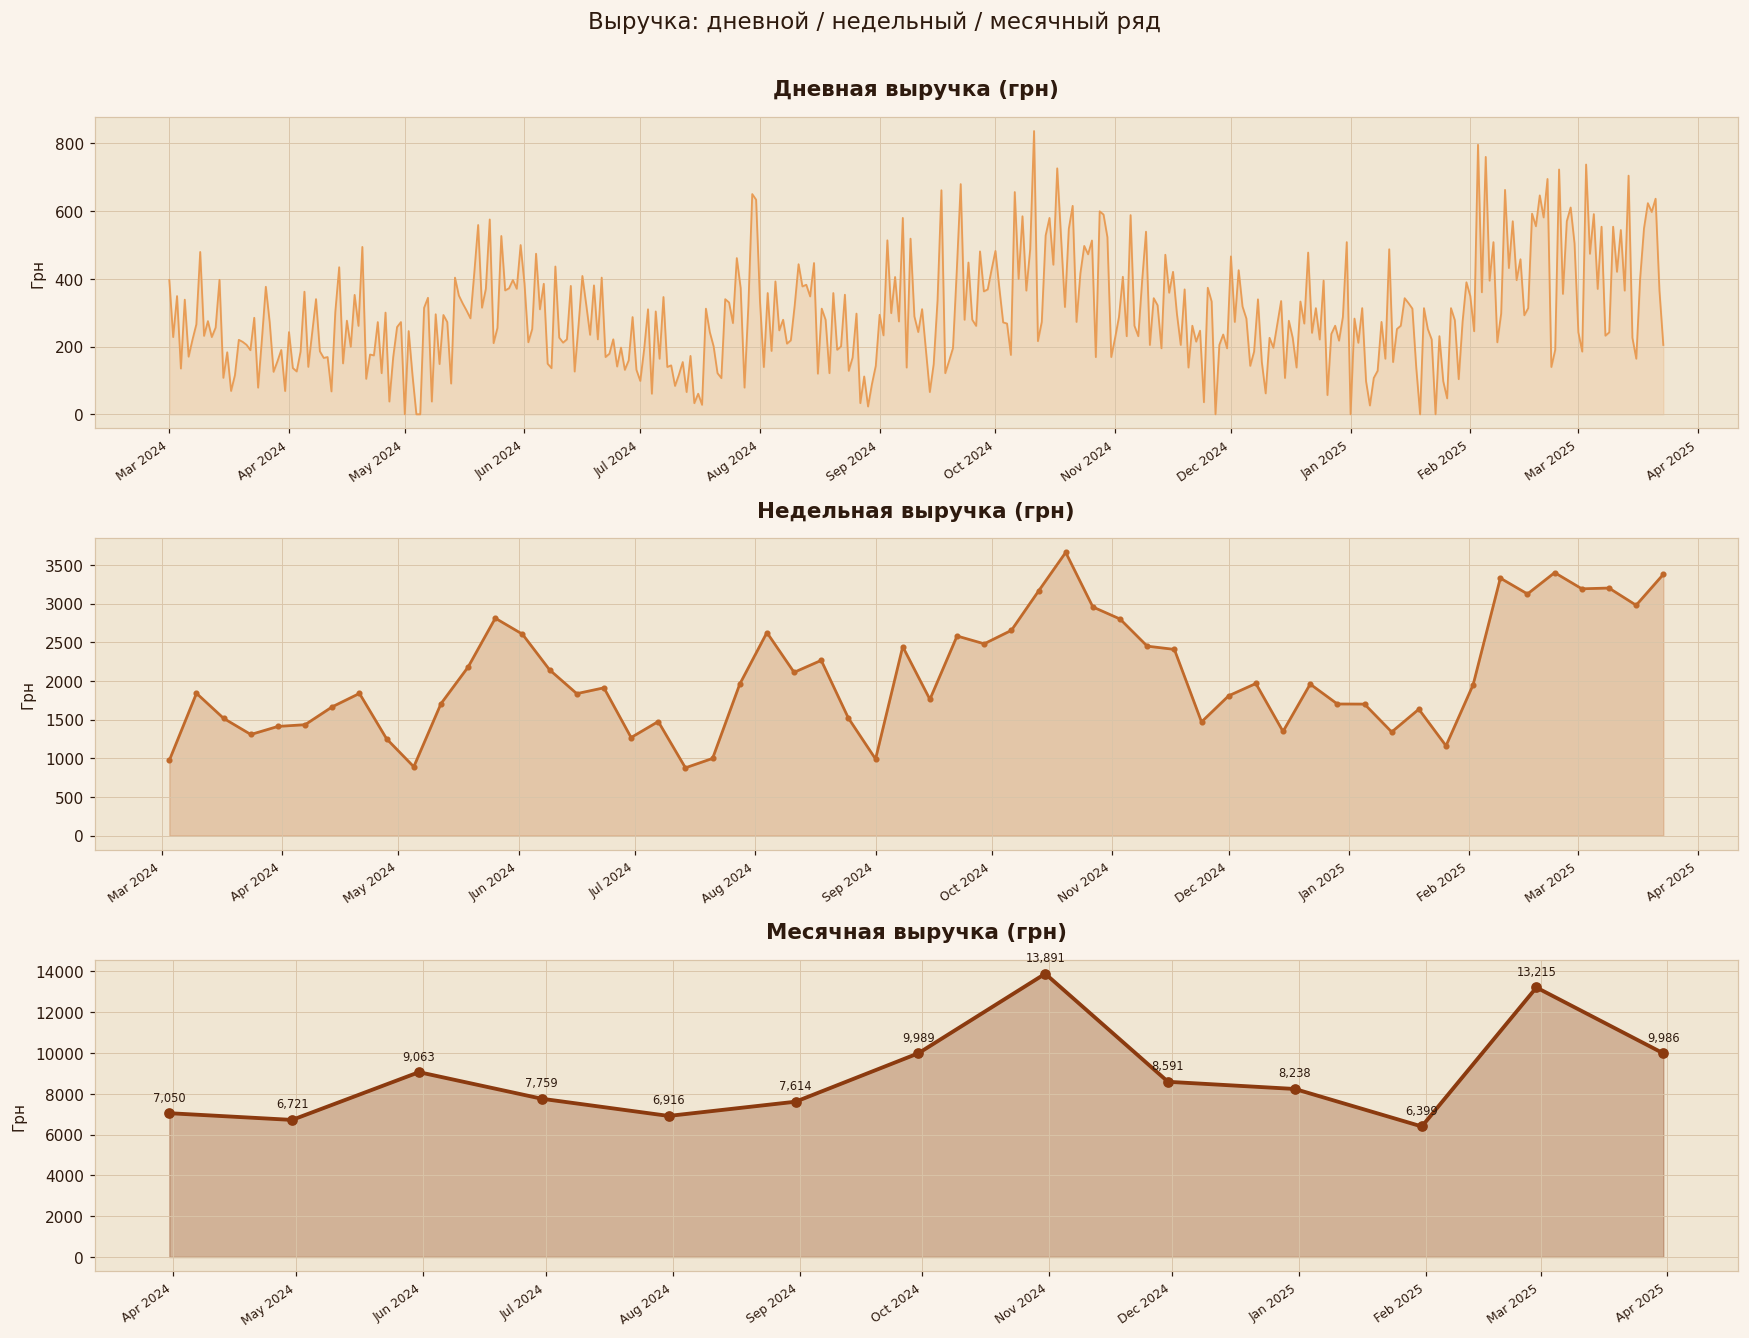

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=False)
fig.patch.set_facecolor(BG)
fig.suptitle('Выручка: дневной / недельный / месячный ряд', fontsize=15, y=1.01)

# Дневной
ax = axes[0]
ax.fill_between(daily['date'], daily['revenue'], alpha=0.18, color=ACCENT3)
ax.plot(daily['date'], daily['revenue'], color=ACCENT3, lw=1.2)
style_ax(ax, 'Дневная выручка (грн)', ylabel='Грн')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# Недельный
ax = axes[1]
ax.fill_between(weekly['date'], weekly['revenue'], alpha=0.25, color=ACCENT2)
ax.plot(weekly['date'], weekly['revenue'], color=ACCENT2, lw=1.8, marker='o', ms=3)
style_ax(ax, 'Недельная выручка (грн)', ylabel='Грн')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# Месячный
ax = axes[2]
ax.fill_between(monthly['date'], monthly['revenue'], alpha=0.3, color=ACCENT)
ax.plot(monthly['date'], monthly['revenue'], color=ACCENT, lw=2.5, marker='o', ms=6)
for x, y in zip(monthly['date'], monthly['revenue']):
    ax.annotate(f'{y:,.0f}', (x, y), textcoords='offset points',
                xytext=(0, 8), ha='center', fontsize=7.5, color=TEXT)
style_ax(ax, 'Месячная выручка (грн)', ylabel='Грн')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax.get_xticklabels(), rotation=35, ha='right', fontsize=8)

plt.tight_layout()
plt.show()

## 🔄 4. Скользящее среднее и тренд
> Убираем дневной шум (MA-7 и MA-30), чтобы увидеть чистый тренд.

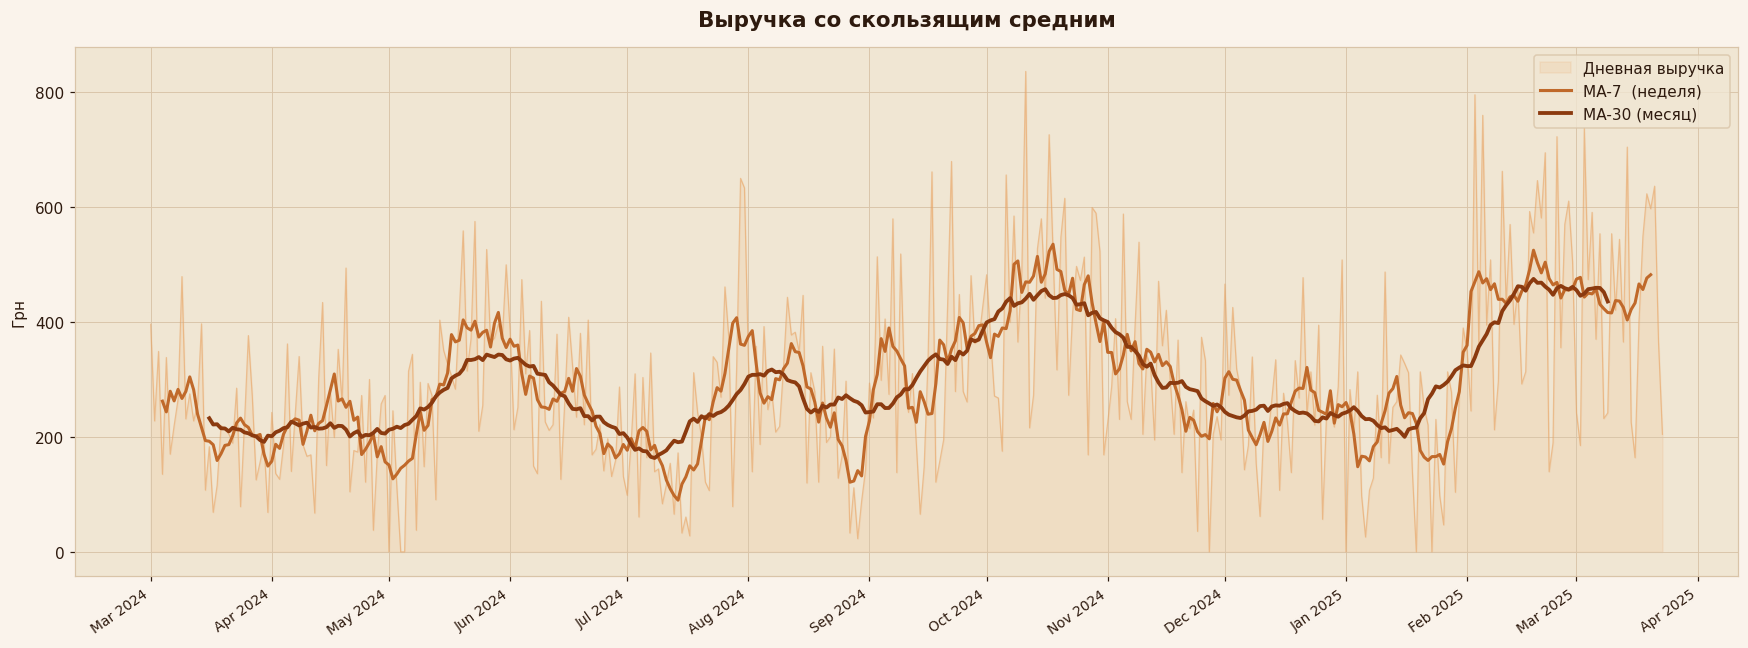

In [11]:
daily['ma7']  = daily['revenue'].rolling(7,  center=True).mean()
daily['ma30'] = daily['revenue'].rolling(30, center=True).mean()

fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor(BG)

ax.fill_between(daily['date'], daily['revenue'], alpha=0.12, color=ACCENT3, label='Дневная выручка')
ax.plot(daily['date'], daily['revenue'],  color=ACCENT3, lw=0.8, alpha=0.5)
ax.plot(daily['date'], daily['ma7'],      color=ACCENT2, lw=2.0, label='MA-7  (неделя)')
ax.plot(daily['date'], daily['ma30'],     color=ACCENT,  lw=2.5, label='MA-30 (месяц)')

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.legend(fontsize=10)
style_ax(ax, 'Выручка со скользящим средним', ylabel='Грн')
plt.tight_layout()
plt.show()

## 🔬 5. STL-декомпозиция: тренд + сезонность + остаток
> Разбиваем ряд на три части. Тренд показывает куда идёт бизнес, сезонность - паттерн недели, остаток - аномалии.

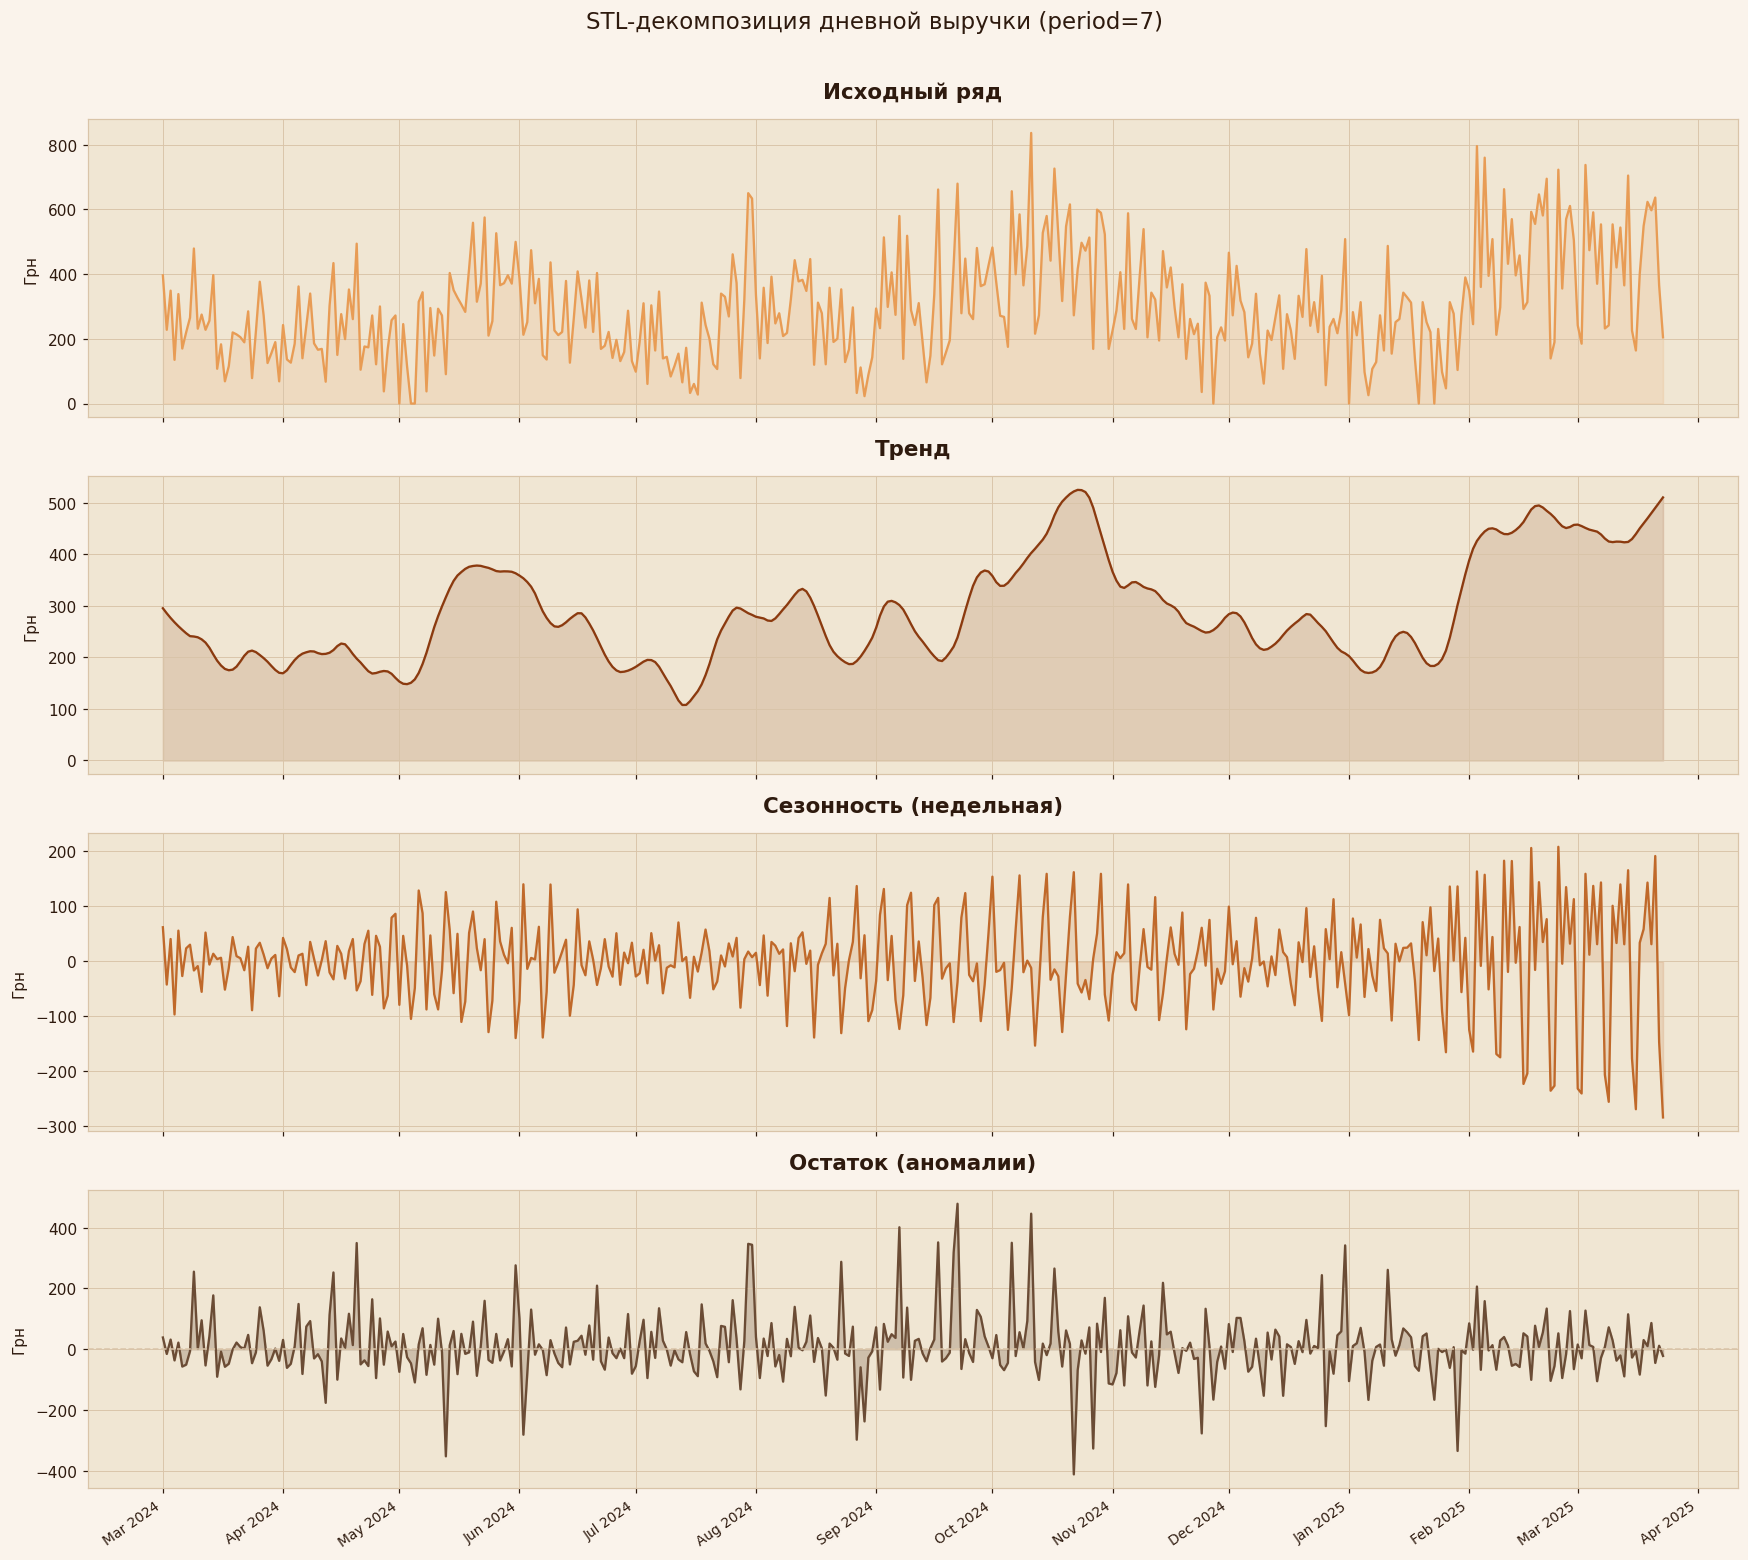

In [13]:
from statsmodels.tsa.seasonal import STL

# Заполняем пропуски нулями (дни без продаж)
daily_full = daily.set_index('date')['revenue'].asfreq('D').fillna(0)

stl = STL(daily_full, period=7, robust=True)
res = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)
fig.patch.set_facecolor(BG)
fig.suptitle('STL-декомпозиция дневной выручки (period=7)', fontsize=15, y=1.01)

parts = [
    (daily_full,     ACCENT3, 'Исходный ряд'),
    (res.trend,      ACCENT,  'Тренд'),
    (res.seasonal,   ACCENT2, 'Сезонность (недельная)'),
    (res.resid,      ACCENT4, 'Остаток (аномалии)'),
]

for ax, (series, color, title) in zip(axes, parts):
    ax.plot(series.index, series.values, color=color, lw=1.5)
    if title == 'Остаток (аномалии)':
        ax.fill_between(series.index, series.values, 0, alpha=0.25, color=color)
        ax.axhline(0, color=GRID, lw=1, linestyle='--')
    else:
        ax.fill_between(series.index, series.values, alpha=0.15, color=color)
    style_ax(ax, title, ylabel='Грн')

axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[-1].get_xticklabels(), rotation=35, ha='right', fontsize=9)

plt.tight_layout()
plt.show()

## 📆 6. Паттерны сезонности: неделя, месяц, час
> Визуально проверяем что обнаружила декомпозиция, есть ли стабильные циклы.

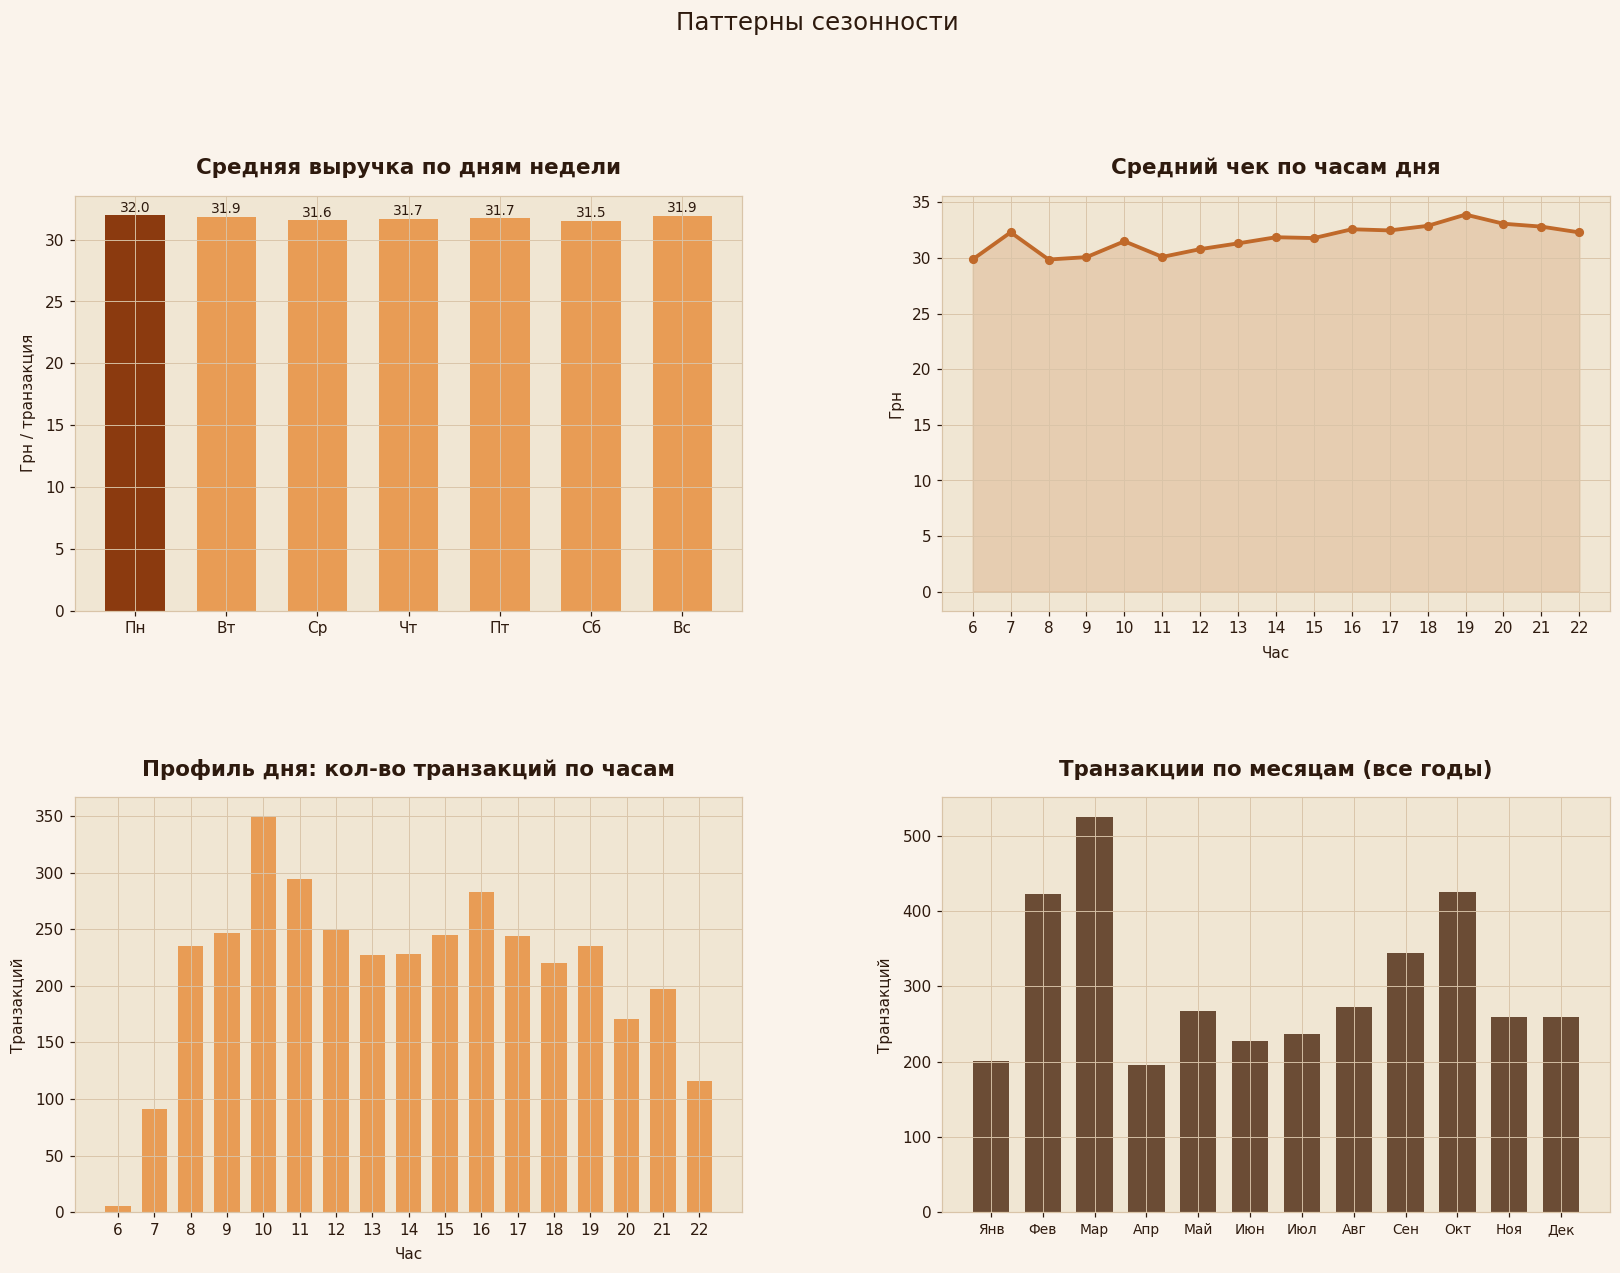

In [15]:
fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor(BG)
gs = GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.3)

# 6a Средняя выручка по дням недели
ax1 = fig.add_subplot(gs[0, 0])
day_order   = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_ru      = ['Пн','Вт','Ср','Чт','Пт','Сб','Вс']
day_avg = df.groupby('weekday')['money'].mean().reindex(day_order)
colors_d = [ACCENT if v == day_avg.max() else ACCENT3 for v in day_avg]
ax1.bar(day_ru, day_avg.values, color=colors_d, edgecolor='none', width=0.65)
for i, v in enumerate(day_avg.values):
    ax1.text(i, v + 0.3, f'{v:.1f}', ha='center', fontsize=9, color=TEXT)
style_ax(ax1, 'Средняя выручка по дням недели', ylabel='Грн / транзакция')

# 6b Средняя выручка по часам
ax2 = fig.add_subplot(gs[0, 1])
hour_avg = df.groupby('hour')['money'].agg(['mean','sum']).reset_index()
ax2.plot(hour_avg['hour'], hour_avg['mean'], color=ACCENT2, lw=2.5, marker='o', ms=5)
ax2.fill_between(hour_avg['hour'], hour_avg['mean'], alpha=0.2, color=ACCENT2)
ax2.set_xticks(hour_avg['hour'])
style_ax(ax2, 'Средний чек по часам дня', xlabel='Час', ylabel='Грн')

# 6c Кол-во транзакций по часам (профиль дня)
ax3 = fig.add_subplot(gs[1, 0])
hour_cnt = df.groupby('hour').size().reset_index(name='count')
ax3.bar(hour_cnt['hour'], hour_cnt['count'], color=ACCENT3, edgecolor='none', width=0.7)
ax3.set_xticks(hour_cnt['hour'])
style_ax(ax3, 'Профиль дня: кол-во транзакций по часам', xlabel='Час', ylabel='Транзакций')

# 6d Кол-во транзакций по месяцам (сезон года)
ax4 = fig.add_subplot(gs[1, 1])
month_num = df['datetime'].dt.month
month_names = ['Янв','Фев','Мар','Апр','Май','Июн',
               'Июл','Авг','Сен','Окт','Ноя','Дек']
month_cnt = df.groupby(month_num).size().reindex(range(1,13), fill_value=0)
ax4.bar(range(12), month_cnt.values, color=ACCENT4, edgecolor='none', width=0.7)
ax4.set_xticks(range(12))
ax4.set_xticklabels(month_names, fontsize=9)
style_ax(ax4, 'Транзакции по месяцам (все годы)', ylabel='Транзакций')

fig.suptitle('Паттерны сезонности', fontsize=16, y=1.02)
plt.show()

## 📊 7. ACF и PACF --- есть ли автокорреляция?
> ACF показывает на каких лагах ряд коррелирует сам с собой. Это ключ к выбору параметров SARIMA.

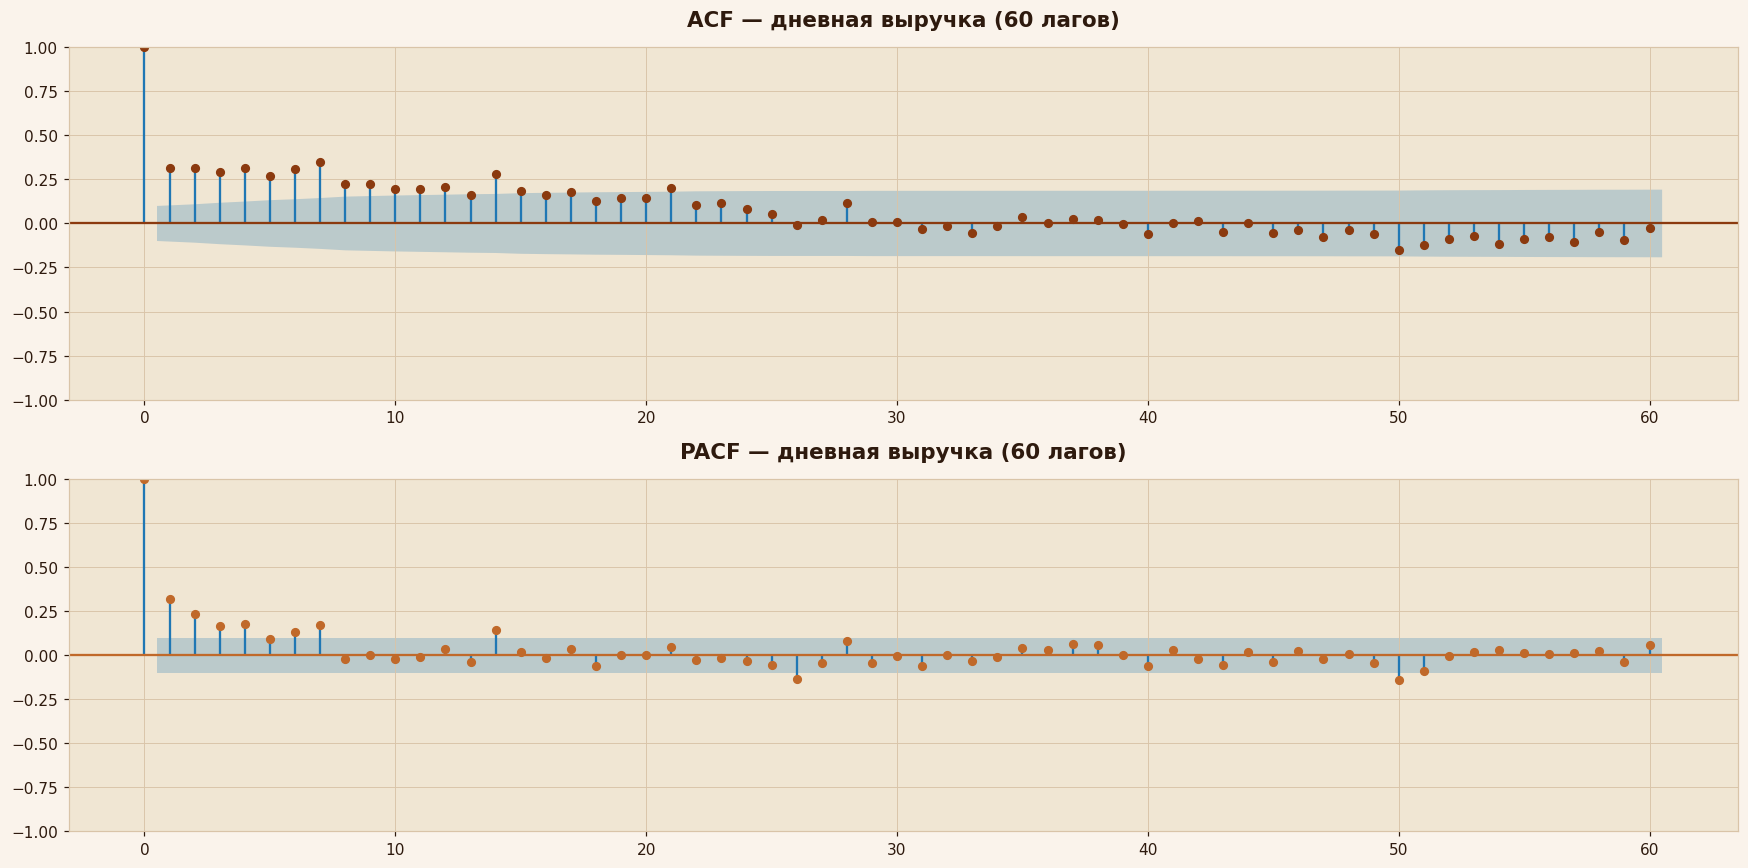

Лаг 7 = недельная сезонность — ожидаем пик на ACF[7], ACF[14], ACF[21]...


In [17]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(16, 8))
fig.patch.set_facecolor(BG)

plot_acf(daily_full,  lags=60, ax=axes[0], color=ACCENT,  alpha=0.05,
         title='ACF — дневная выручка (60 лагов)')
plot_pacf(daily_full, lags=60, ax=axes[1], color=ACCENT2, alpha=0.05, method='ywm',
          title='PACF — дневная выручка (60 лагов)')

for ax in axes:
    ax.set_facecolor(PANEL)
    ax.spines[['top','right','left','bottom']].set_color(GRID)
    # Перекрасим линии ACF/PACF
    for line in ax.get_lines():
        if line.get_color() not in (ACCENT, ACCENT2):
            line.set_color(GRID)

plt.tight_layout()
plt.show()

print('Лаг 7 = недельная сезонность — ожидаем пик на ACF[7], ACF[14], ACF[21]...')

## 🧪 8. Тест Дики-Фуллера: стационарен ли ряд?
> SARIMA и Prophet работают лучше если ряд стационарен (или мы знаем сколько раз его дифференцировать).

In [19]:
from statsmodels.tsa.stattools import adfuller

def adf_report(series, name):
    result = adfuller(series.dropna())
    print(f'Ряд: {name}')
    print(f'  ADF-статистика : {result[0]:.4f}')
    print(f'  p-value        : {result[1]:.4f}')
    print(f'  Критические значения: ', {k: f'{v:.3f}' for k, v in result[4].items()})
    verdict = '✅ СТАЦИОНАРЕН' if result[1] < 0.05 else '❌ НЕСТАЦИОНАРЕН (нужна дифференциация)'
    print(f'  Вывод: {verdict}')

adf_report(daily_full,              'Дневная выручка (исходная)')
adf_report(daily_full.diff(),       'Дневная выручка (1-е различие)')
adf_report(daily_full.diff().diff(),'Дневная выручка (2-е различие)')

Ряд: Дневная выручка (исходная)
  ADF-статистика : -3.0497
  p-value        : 0.0305
  Критические значения:  {'1%': '-3.448', '5%': '-2.869', '10%': '-2.571'}
  Вывод: ✅ СТАЦИОНАРЕН
Ряд: Дневная выручка (1-е различие)
  ADF-статистика : -8.1602
  p-value        : 0.0000
  Критические значения:  {'1%': '-3.448', '5%': '-2.869', '10%': '-2.571'}
  Вывод: ✅ СТАЦИОНАРЕН
Ряд: Дневная выручка (2-е различие)
  ADF-статистика : -9.3047
  p-value        : 0.0000
  Критические значения:  {'1%': '-3.448', '5%': '-2.869', '10%': '-2.571'}
  Вывод: ✅ СТАЦИОНАРЕН


## 🔮 9. SARIMA | прогноз на следующий месяц
> Используем недельную сезонность (m=7). Обучаем на всём ряде, прогнозируем 30 дней вперёд.

In [21]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# SARIMA(1,1,1)(1,1,1)[7] — базовые параметры с недельной сезонностью
# Поменяйте p,d,q / P,D,Q если хотите экспериментировать
model = SARIMAX(
    daily_full,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)
result = model.fit(disp=False)
print(result.summary())

                                     SARIMAX Results                                     
Dep. Variable:                           revenue   No. Observations:                  388
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood               -2370.258
Date:                           Sat, 06 Jun 2026   AIC                           4750.516
Time:                                   19:43:38   BIC                           4770.097
Sample:                               03-01-2024   HQIC                          4758.293
                                    - 03-23-2025                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0334      0.062     -0.539      0.590      -0.155       0.088
ma.L1         -0.8197      0.032    -25.273

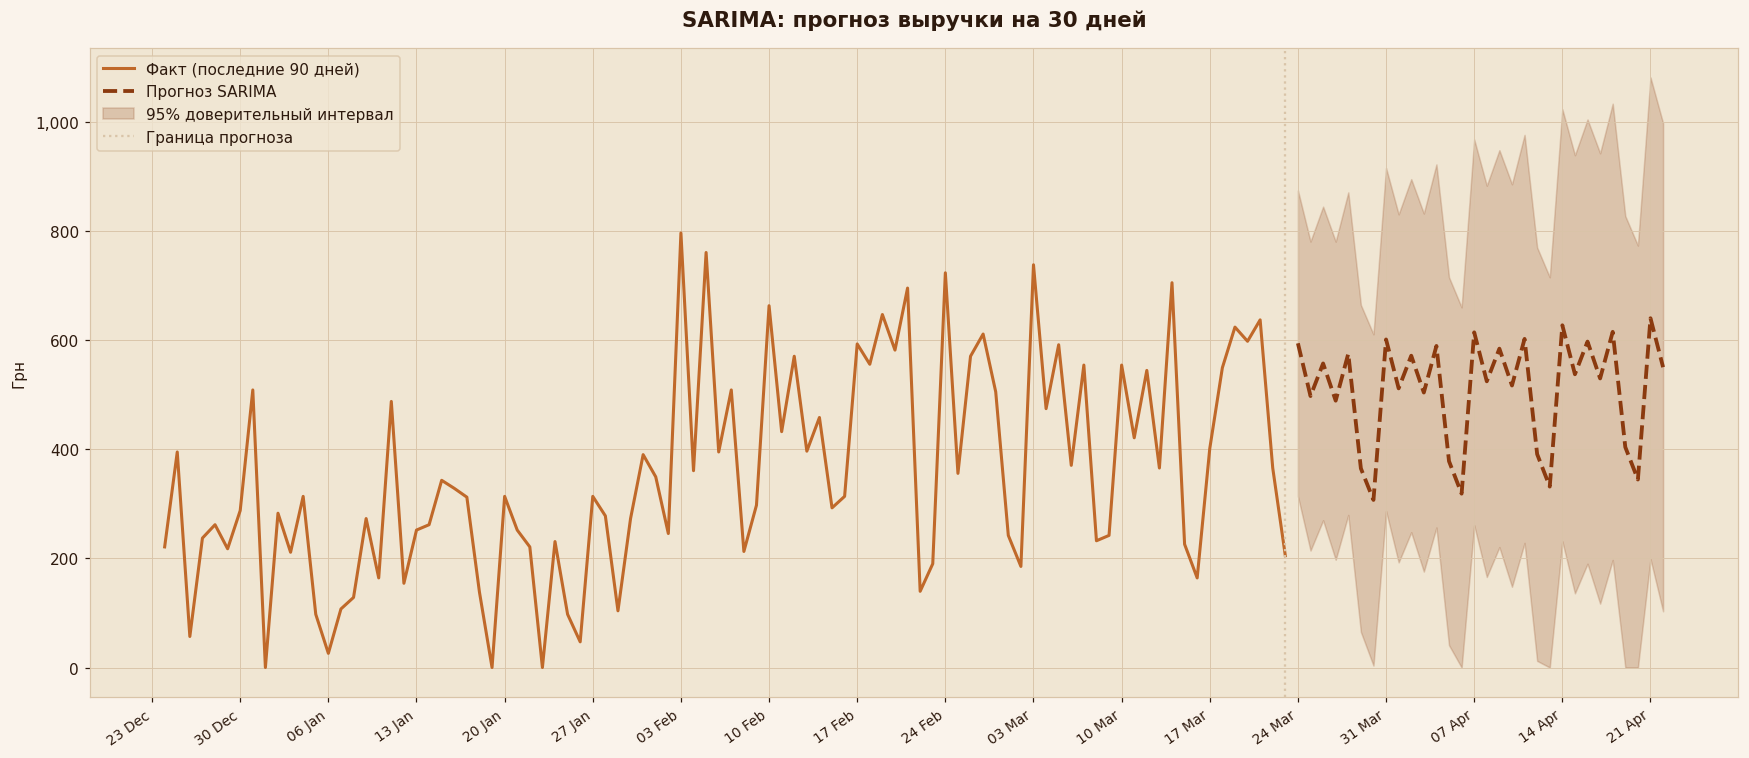


📌 Прогнозируемая выручка на 30 дней: 15,262 грн


In [22]:
FORECAST_DAYS = 30

forecast = result.get_forecast(steps=FORECAST_DAYS)
forecast_mean = forecast.predicted_mean
conf_int      = forecast.conf_int(alpha=0.05)  # 95% CI

# Последние 90 дней исторических данных + прогноз
history_tail = daily_full[-90:]

fig, ax = plt.subplots(figsize=(16, 7))
fig.patch.set_facecolor(BG)

# История
ax.plot(history_tail.index, history_tail.values,
        color=ACCENT2, lw=2, label='Факт (последние 90 дней)')

# Прогноз
ax.plot(forecast_mean.index, forecast_mean.values,
        color=ACCENT, lw=2.5, linestyle='--', label='Прогноз SARIMA')

# Доверительный интервал
ax.fill_between(
    conf_int.index,
    conf_int.iloc[:, 0].clip(lower=0),
    conf_int.iloc[:, 1],
    alpha=0.2, color=ACCENT, label='95% доверительный интервал'
)

# Вертикальная черта 'сегодня'
ax.axvline(daily_full.index[-1], color=GRID, lw=1.5, linestyle=':', label='Граница прогноза')

ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.setp(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.legend(fontsize=10)
style_ax(ax, f'SARIMA: прогноз выручки на {FORECAST_DAYS} дней', ylabel='Грн')
plt.tight_layout()
plt.show()

total_forecast = forecast_mean.clip(lower=0).sum()
print(f'\n📌 Прогнозируемая выручка на {FORECAST_DAYS} дней: {total_forecast:,.0f} грн')

## 🩺 10. Диагностика модели SARIMA
> Остатки должны быть случайными (белый шум). Если есть паттерн --- модель что-то пропустила.

In [24]:
pip install -U statsmodels

Note: you may need to restart the kernel to use updated packages.


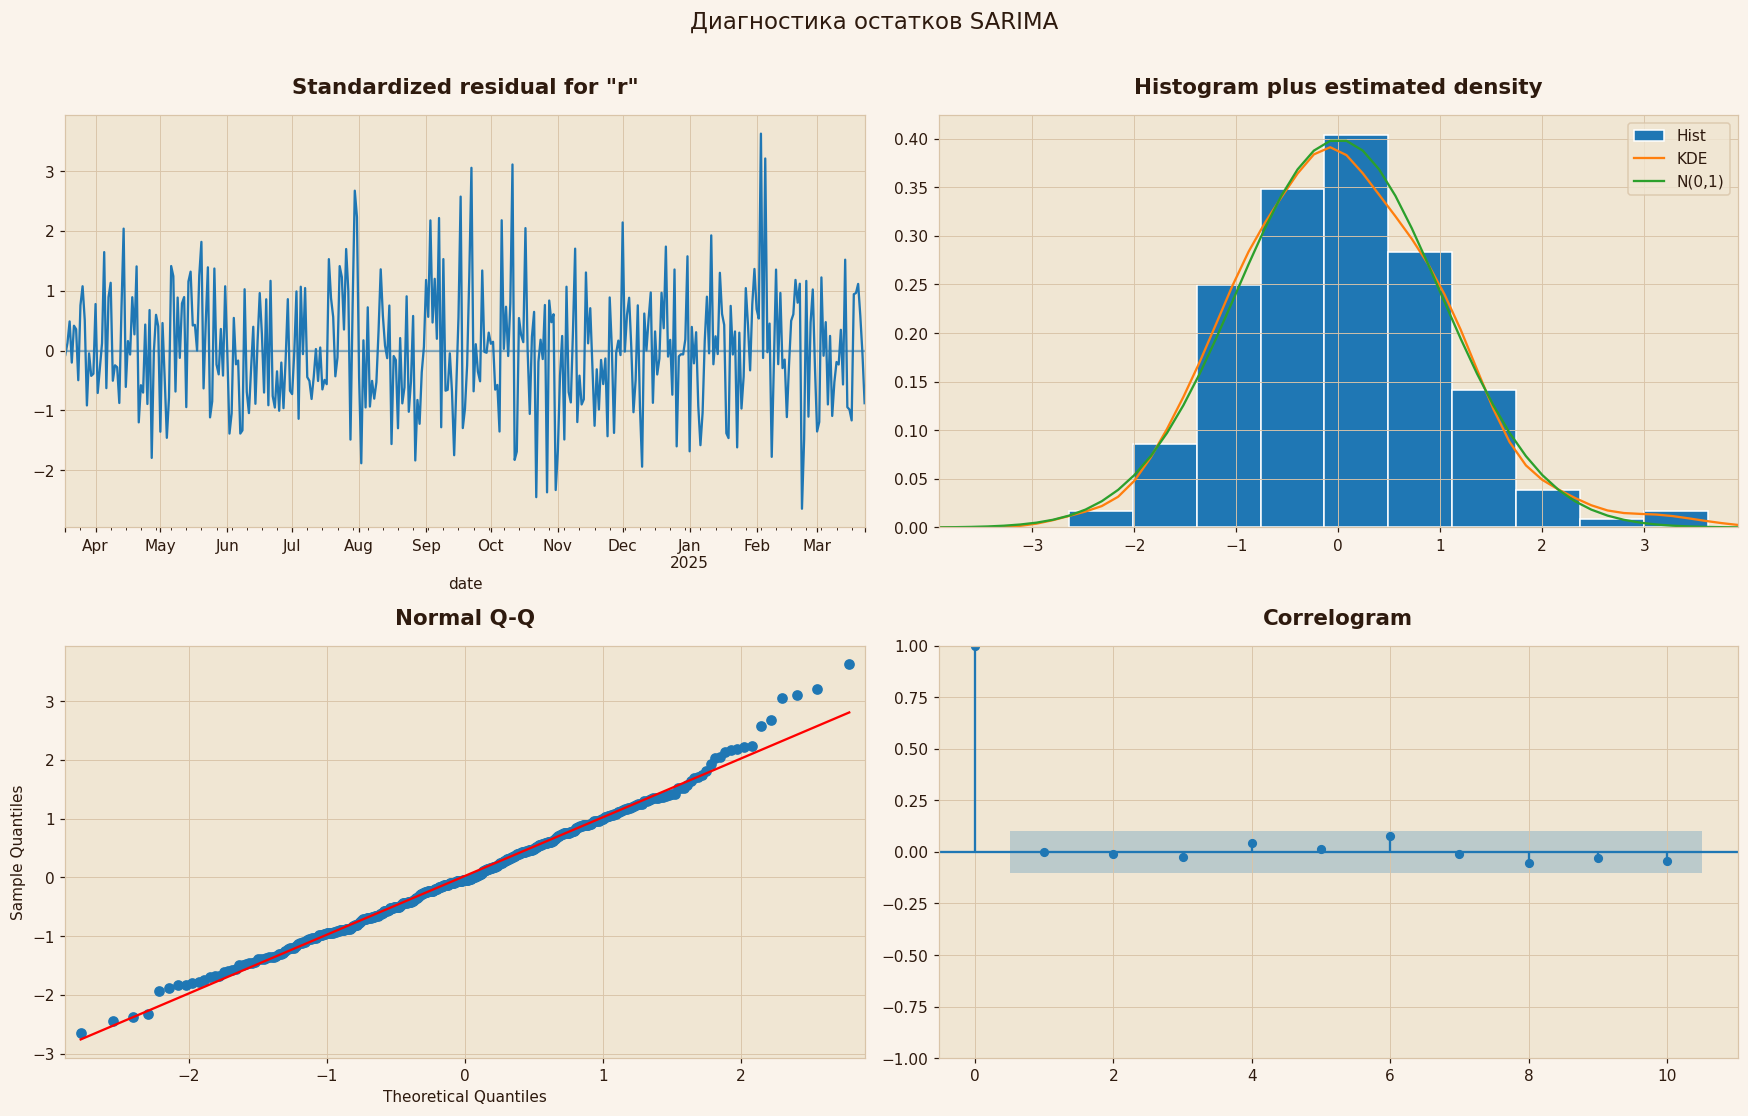

In [25]:
fig = result.plot_diagnostics(figsize=(16, 10))
fig.patch.set_facecolor(BG)
for ax in fig.axes:
    ax.set_facecolor(PANEL)
    ax.tick_params(colors=TEXT)
    ax.xaxis.label.set_color(TEXT)
    ax.yaxis.label.set_color(TEXT)
    ax.title.set_color(TEXT)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID)
plt.suptitle('Диагностика остатков SARIMA', fontsize=15, y=1.01, color=TEXT)
plt.tight_layout()
plt.show()

## 🔮 11. Prophet | альтернативный прогноз
> Prophet от Meta автоматически находит тренды и праздничные аномалии. Хорош на коротких рядах и при пропусках.

In [27]:
from prophet import Prophet

# Prophet ожидает колонки 'ds' и 'y'
prophet_df = daily_full.reset_index().rename(columns={'date': 'ds', 'revenue': 'y'})
prophet_df['y'] = prophet_df['y'].clip(lower=0)

m = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative',   # подходит когда амплитуда растёт вместе с трендом
    changepoint_prior_scale=0.05         # чувствительность к изломам тренда
)
m.fit(prophet_df)

future = m.make_future_dataframe(periods=30)
forecast_p = m.predict(future)

print('✅ Prophet обучен')
forecast_p[['ds','yhat','yhat_lower','yhat_upper']].tail(10)

19:43:41 - cmdstanpy - INFO - Chain [1] start processing
19:43:41 - cmdstanpy - INFO - Chain [1] done processing


✅ Prophet обучен


,ds,yhat,yhat_lower,yhat_upper
408,2025-04-13,413.252286,256.728341,587.314180
409,2025-04-14,545.762922,397.869687,715.343539
410,2025-04-15,543.003047,376.084563,701.569968
411,2025-04-16,478.912429,315.091359,645.253141
412,2025-04-17,469.272539,304.487561,643.389047
413,2025-04-18,482.741221,322.678562,650.878827
414,2025-04-19,401.088906,233.295301,563.639127
415,2025-04-20,350.318033,193.256922,512.958091
416,2025-04-21,476.755772,305.149682,628.860879
417,2025-04-22,468.046747,291.882057,630.117015


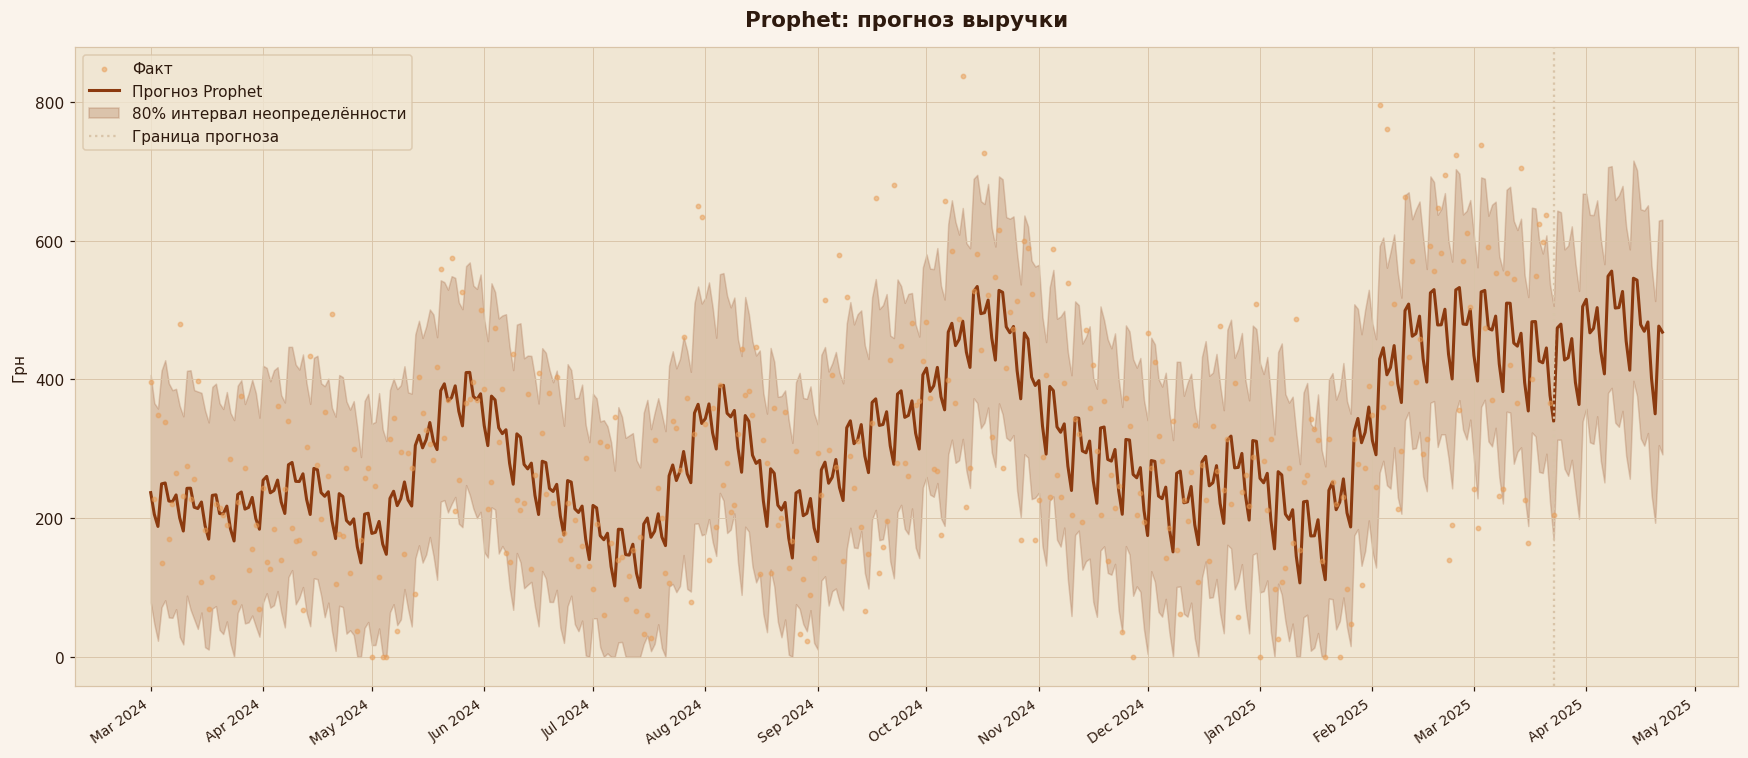


📌 Prophet: прогноз на 30 дней = 14,066 грн


In [28]:
# Кастомный график prophet вместо стандартного
fig, ax = plt.subplots(figsize=(16, 7))
fig.patch.set_facecolor(BG)

# История
ax.scatter(prophet_df['ds'], prophet_df['y'],
           s=8, color=ACCENT3, alpha=0.5, label='Факт', zorder=3)

# Прогноз
ax.plot(forecast_p['ds'], forecast_p['yhat'],
        color=ACCENT, lw=2, label='Прогноз Prophet')

# Доверительный интервал
ax.fill_between(
    forecast_p['ds'],
    forecast_p['yhat_lower'].clip(lower=0),
    forecast_p['yhat_upper'],
    alpha=0.2, color=ACCENT, label='80% интервал неопределённости'
)

ax.axvline(prophet_df['ds'].max(), color=GRID, lw=1.5, linestyle=':', label='Граница прогноза')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.legend(fontsize=10)
style_ax(ax, 'Prophet: прогноз выручки', ylabel='Грн')
plt.tight_layout()
plt.show()

p30 = forecast_p[forecast_p['ds'] > prophet_df['ds'].max()]['yhat'].clip(lower=0).sum()
print(f'\n📌 Prophet: прогноз на 30 дней = {p30:,.0f} грн')

## 🧩 12. Компоненты Prophet: тренд + сезонности
> Разбиваем прогноз на части,  это главный инсайт модели.

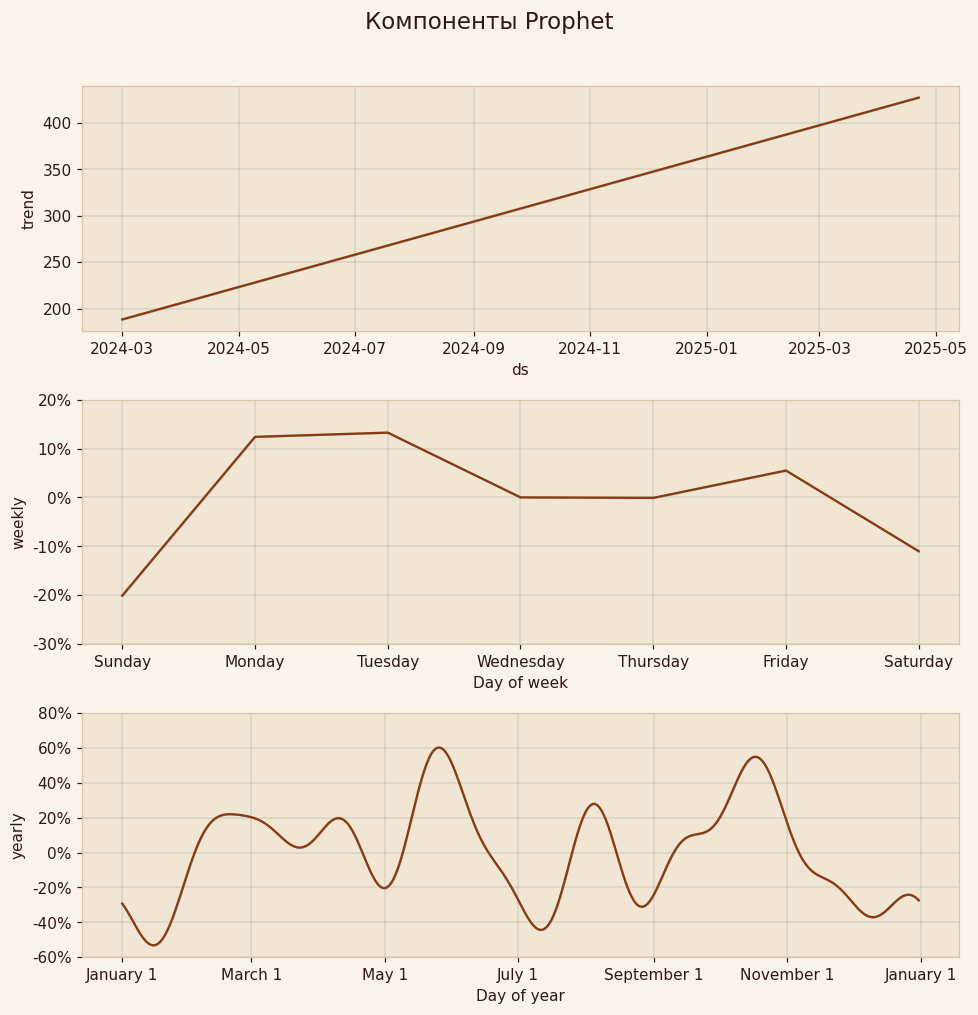

In [30]:
fig2 = m.plot_components(forecast_p)
fig2.patch.set_facecolor(BG)
for ax in fig2.axes:
    ax.set_facecolor(PANEL)
    ax.tick_params(colors=TEXT)
    ax.xaxis.label.set_color(TEXT)
    ax.yaxis.label.set_color(TEXT)
    ax.title.set_color(TEXT)
    for line in ax.get_lines():
        line.set_color(ACCENT)
    for coll in ax.collections:
        coll.set_facecolor(ACCENT3)
        coll.set_alpha(0.25)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID)
plt.suptitle('Компоненты Prophet', fontsize=15, y=1.02, color=TEXT)
plt.tight_layout()
plt.show()

## ⚔️ 13. Сравнение прогнозов: SARIMA vs Prophet
> Смотрим оба прогноза на одном графике: где они согласны, а где расходятся.

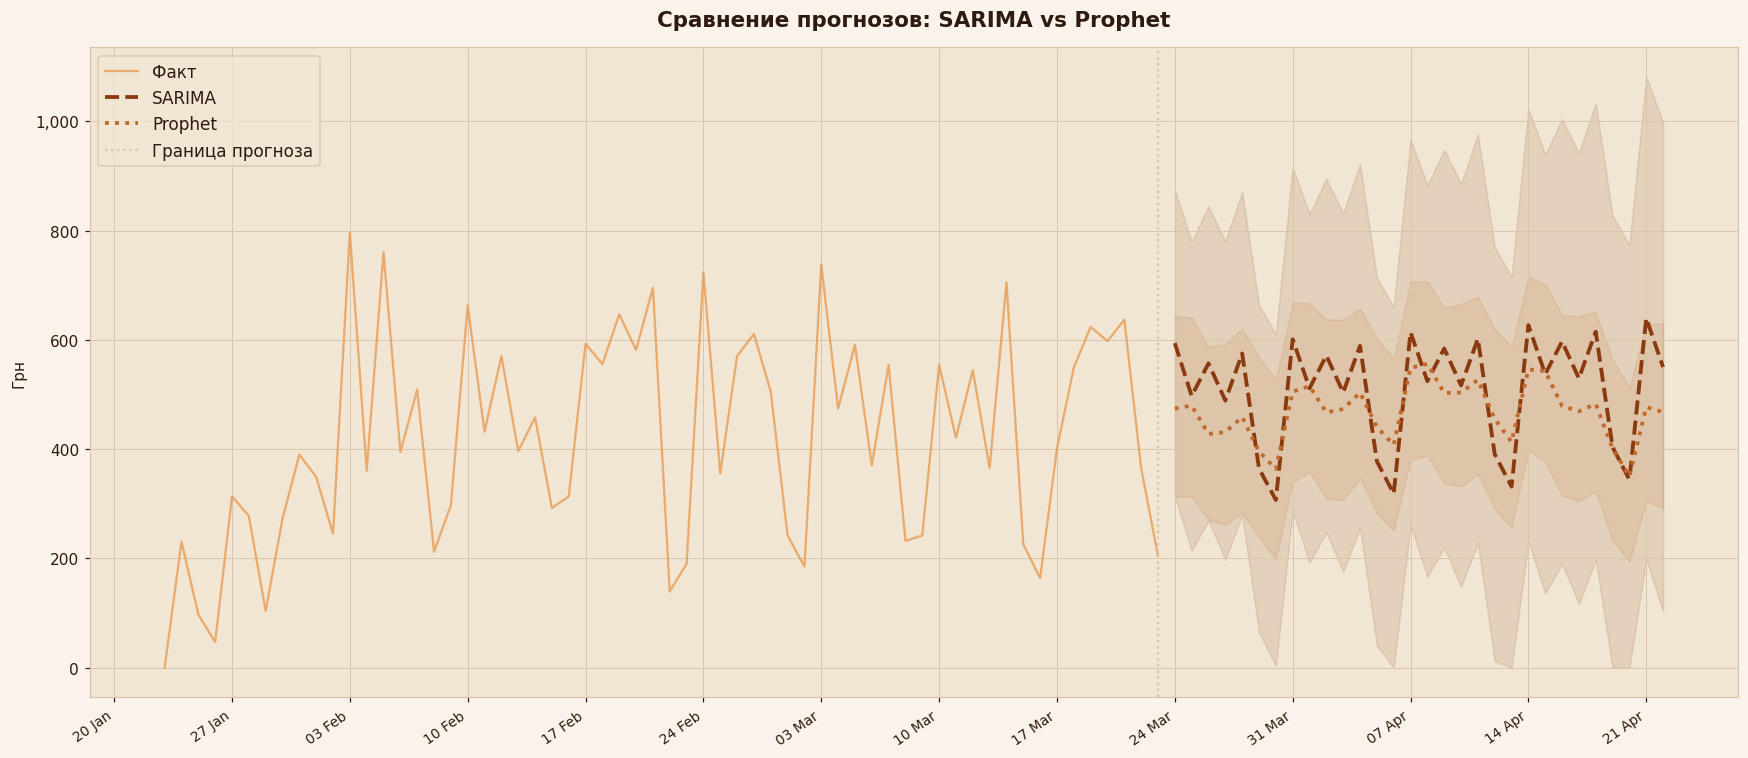

SARIMA  → 15,262 грн за 30 дней
Prophet → 14,066 грн за 30 дней


In [32]:
# Выравниваем прогнозы на один диапазон дат
sarima_dates = forecast_mean.index
prophet_future = forecast_p[forecast_p['ds'].isin(sarima_dates)].set_index('ds')

fig, ax = plt.subplots(figsize=(16, 7))
fig.patch.set_facecolor(BG)

# Последние 60 дней факта
ax.plot(daily_full[-60:].index, daily_full[-60:].values,
        color=ACCENT3, lw=1.5, alpha=0.8, label='Факт')

# SARIMA
ax.plot(forecast_mean.index, forecast_mean.clip(lower=0).values,
        color=ACCENT, lw=2.5, linestyle='--', label='SARIMA')
ax.fill_between(conf_int.index,
                conf_int.iloc[:,0].clip(lower=0), conf_int.iloc[:,1],
                alpha=0.12, color=ACCENT)

# Prophet
ax.plot(prophet_future.index, prophet_future['yhat'].clip(lower=0).values,
        color=ACCENT2, lw=2.5, linestyle=':', label='Prophet')
ax.fill_between(prophet_future.index,
                prophet_future['yhat_lower'].clip(lower=0),
                prophet_future['yhat_upper'],
                alpha=0.12, color=ACCENT2)

ax.axvline(daily_full.index[-1], color=GRID, lw=1.5, linestyle=':', label='Граница прогноза')
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.setp(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.legend(fontsize=11)
style_ax(ax, 'Сравнение прогнозов: SARIMA vs Prophet', ylabel='Грн')
plt.tight_layout()
plt.show()

print(f'SARIMA  → {forecast_mean.clip(lower=0).sum():,.0f} грн за 30 дней')
print(f'Prophet → {prophet_future["yhat"].clip(lower=0).sum():,.0f} грн за 30 дней')

## ☕ 14. Прогноз по топ-напиткам
> Prophet на недельных рядах для каждого топ-напитка. Видим какой напиток растёт, а какой стагнирует.

19:43:42 - cmdstanpy - INFO - Chain [1] start processing
19:43:42 - cmdstanpy - INFO - Chain [1] done processing
19:43:42 - cmdstanpy - INFO - Chain [1] start processing
19:43:43 - cmdstanpy - INFO - Chain [1] done processing
19:43:43 - cmdstanpy - INFO - Chain [1] start processing
19:43:43 - cmdstanpy - INFO - Chain [1] done processing
19:43:43 - cmdstanpy - INFO - Chain [1] start processing
19:43:43 - cmdstanpy - INFO - Chain [1] done processing


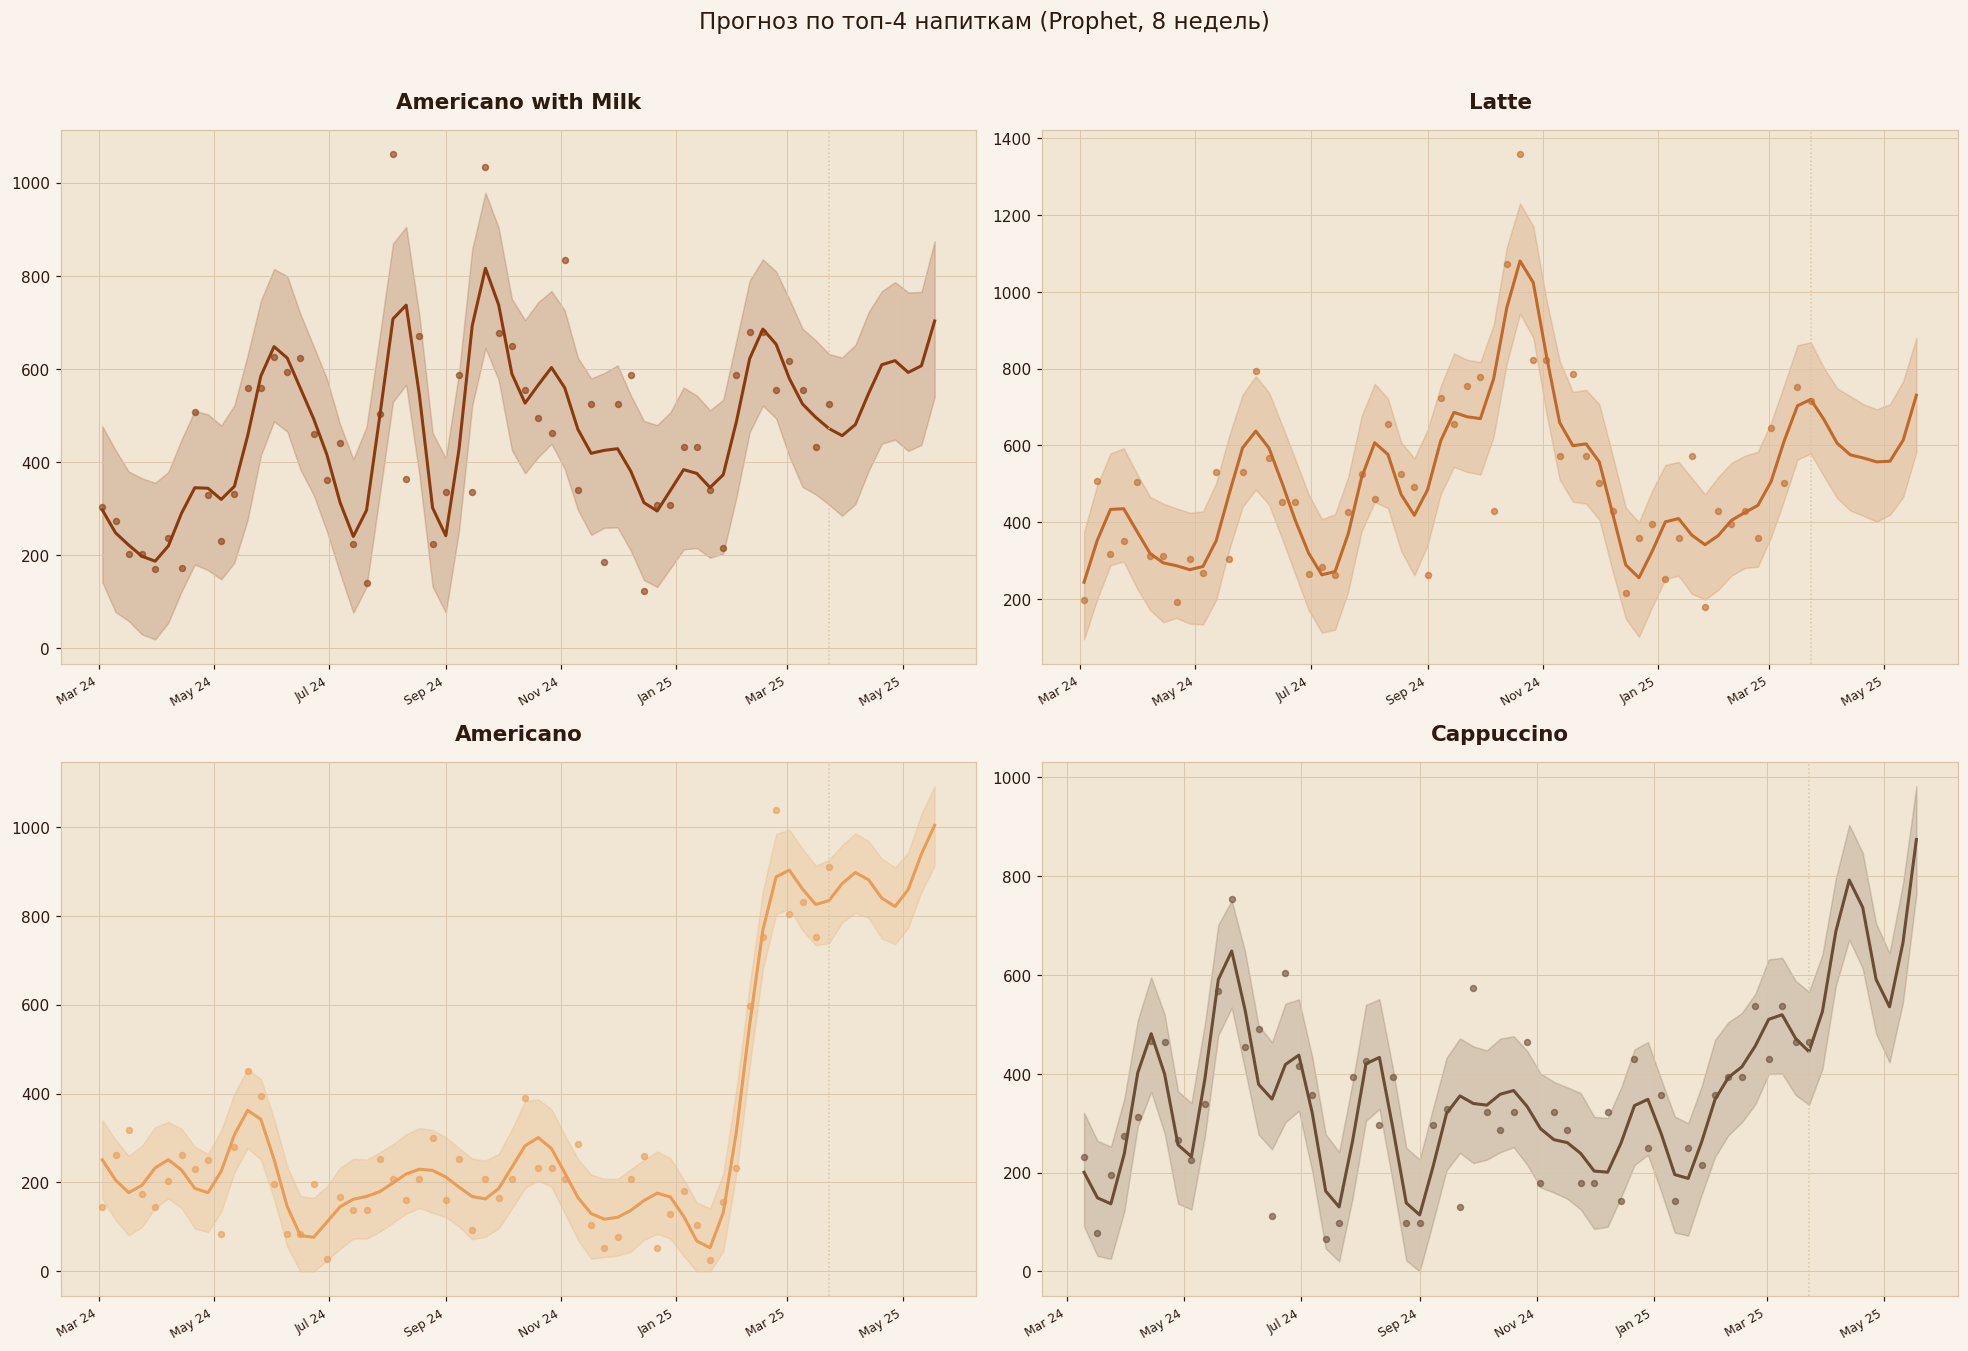

In [34]:
top_drinks = df['coffee_name'].value_counts().head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.patch.set_facecolor(BG)
fig.suptitle('Прогноз по топ-4 напиткам (Prophet, 8 недель)', fontsize=15, y=1.02)

colors_drinks = [ACCENT, ACCENT2, ACCENT3, ACCENT4]

for ax, drink, color in zip(axes.flatten(), top_drinks, colors_drinks):
    drink_daily = (
        df[df['coffee_name'] == drink]
        .set_index('datetime')
        .resample('W')['money']
        .sum()
        .reset_index()
        .rename(columns={'datetime': 'ds', 'money': 'y'})
    )

    md_drink = Prophet(
        weekly_seasonality=False,
        yearly_seasonality=True,
        changepoint_prior_scale=0.05
    )
    md_drink.fit(drink_daily)
    fut = md_drink.make_future_dataframe(periods=8, freq='W')
    fc  = md_drink.predict(fut)

    ax.scatter(drink_daily['ds'], drink_daily['y'], s=15, color=color, alpha=0.6, zorder=3)
    ax.plot(fc['ds'], fc['yhat'].clip(lower=0), color=color, lw=2)
    ax.fill_between(fc['ds'],
                    fc['yhat_lower'].clip(lower=0), fc['yhat_upper'],
                    alpha=0.2, color=color)
    ax.axvline(drink_daily['ds'].max(), color=GRID, lw=1, linestyle=':')
    ax.set_facecolor(PANEL)
    ax.spines[['top','right','left','bottom']].set_color(GRID)
    ax.tick_params(colors=TEXT)
    ax.set_title(drink, color=TEXT, fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)

plt.tight_layout()
plt.show()

## 🚨 15. Обнаружение аномалий
> Дни с выручкой за пределами ±2σ от скользящего среднего: возможные поломки, акции или нетипичный спрос.

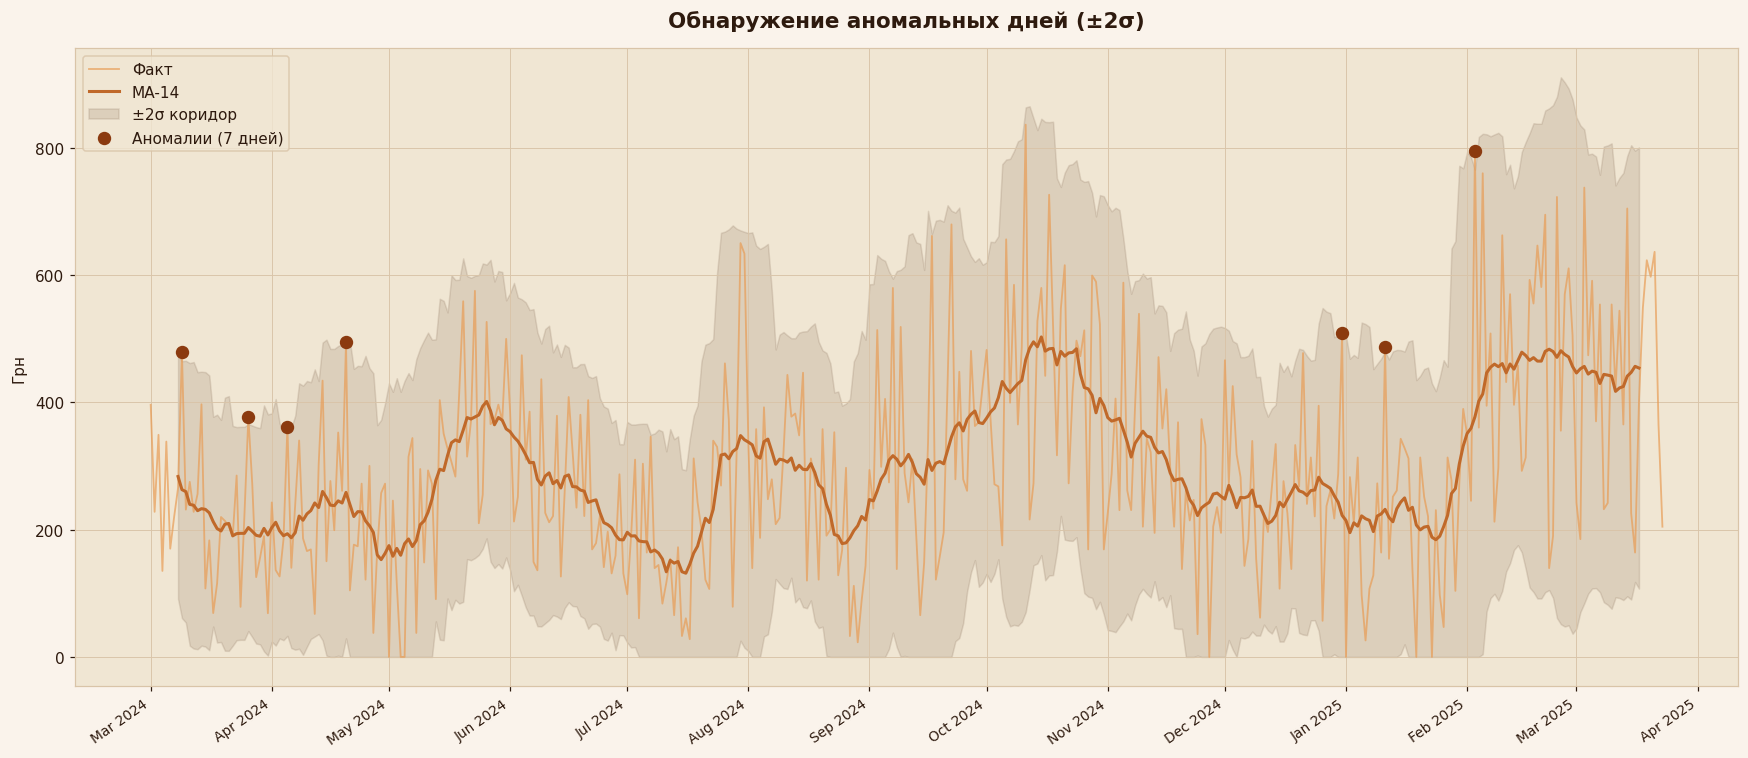

Топ-5 аномальных дней:
      date  revenue
2025-02-03   796.00
2024-12-31   508.46
2024-04-20   494.30
2025-01-11   487.40
2024-03-09   479.40


In [36]:
win = 14
daily['roll_mean'] = daily['revenue'].rolling(win, center=True).mean()
daily['roll_std']  = daily['revenue'].rolling(win, center=True).std()
daily['upper']     = daily['roll_mean'] + 2 * daily['roll_std']
daily['lower']     = (daily['roll_mean'] - 2 * daily['roll_std']).clip(lower=0)
daily['anomaly']   = (daily['revenue'] > daily['upper']) | (daily['revenue'] < daily['lower'])

fig, ax = plt.subplots(figsize=(16, 7))
fig.patch.set_facecolor(BG)

ax.plot(daily['date'], daily['revenue'], color=ACCENT3, lw=1.2, alpha=0.7, label='Факт')
ax.plot(daily['date'], daily['roll_mean'], color=ACCENT2, lw=2, label=f'MA-{win}')
ax.fill_between(daily['date'], daily['lower'], daily['upper'],
                alpha=0.15, color=ACCENT4, label='±2σ коридор')

anom = daily[daily['anomaly']]
ax.scatter(anom['date'], anom['revenue'],
           color=ACCENT, s=60, zorder=5, label=f'Аномалии ({len(anom)} дней)')

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.legend(fontsize=10)
style_ax(ax, 'Обнаружение аномальных дней (±2σ)', ylabel='Грн')
plt.tight_layout()
plt.show()

print('Топ-5 аномальных дней:')
print(anom.nlargest(5, 'revenue')[['date','revenue']].to_string(index=False))

## 📋 16. Итоги и выводы
> Что показал анализ временных рядов?

In [59]:
sarima_30  = forecast_mean.clip(lower=0).sum()
prophet_30 = prophet_future['yhat'].clip(lower=0).sum()
n_anom     = daily['anomaly'].sum()

print('=' * 60)
print('📋 ВЫВОДЫ TIME SERIES ANALYSIS')
print('=' * 60)
print(f"""
📈 Тренд
   MA-30 показывает направление бизнеса — см. секцию 4
   STL-декомпозиция выделила чистый тренд без шума

📅 Сезонность
   Недельный цикл подтверждён ACF (пики на лагах 7, 14, 21)
   Месячный профиль показывает сезонные колебания по месяцам

🔮 Прогноз на 30 дней
   SARIMA  : {sarima_30:>10,.0f} грн
   Prophet : {prophet_30:>10,.0f} грн
   Среднее : {(sarima_30 + prophet_30)/2:>10,.0f} грн

🚨 Аномалии
   Обнаружено {n_anom} аномальных дней (±2σ)
   Стоит проверить каждый — поломка или акция?

💡 Как можно улучшить
   - Добавить внешние регрессоры (погода, праздники) в Prophet
   - Автоматический подбор SARIMA через pmdarima.auto_arima
   - Оценка точности: MAE, RMSE, MAPE на holdout-выборке
""")

📋 ВЫВОДЫ TIME SERIES ANALYSIS

📈 Тренд
   MA-30 показывает направление бизнеса — см. секцию 4
   STL-декомпозиция выделила чистый тренд без шума

📅 Сезонность
   Недельный цикл подтверждён ACF (пики на лагах 7, 14, 21)
   Месячный профиль показывает сезонные колебания по месяцам

🔮 Прогноз на 30 дней
   SARIMA  :     15,262 грн
   Prophet :     14,066 грн
   Среднее :     14,664 грн

🚨 Аномалии
   Обнаружено 7 аномальных дней (±2σ)
   Стоит проверить каждый — поломка или акция?

💡 Как можно улучшить
   - Добавить внешние регрессоры (погода, праздники) в Prophet
   - Автоматический подбор SARIMA через pmdarima.auto_arima
   - Оценка точности: MAE, RMSE, MAPE на holdout-выборке

